# Auto MPG Regression Analysis
This notebook develops linear and polynomial regression models to predict fuel efficiency (MPG) based on engine characteristics.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, learning_curve, validation_curve
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Set style for plots
sns.set_theme(style="whitegrid")


## Question 1 — Load Dataset

In [2]:
# Load Auto MPG dataset from Seaborn
mpg = sns.load_dataset('mpg')

# Display first 10 rows, dataset shape, column names
print("Dataset shape:", mpg.shape)
print("Column names:", mpg.columns.tolist())
display(mpg.head(10))


Dataset shape: (398, 9)
Column names: ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model_year', 'origin', 'name']


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino
5,15.0,8,429.0,198.0,4341,10.0,70,usa,ford galaxie 500
6,14.0,8,454.0,220.0,4354,9.0,70,usa,chevrolet impala
7,14.0,8,440.0,215.0,4312,8.5,70,usa,plymouth fury iii
8,14.0,8,455.0,225.0,4425,10.0,70,usa,pontiac catalina
9,15.0,8,390.0,190.0,3850,8.5,70,usa,amc ambassador dpl


## Question 2 — Data Cleaning

In [3]:
# Handle missing values in mpg and horsepower.
# We will use median to fill missing values for 'horsepower' because it is robust to outliers.
# 'mpg' does not have missing values in the seaborn dataset, but we would drop rows if it did (as it is the target).

mpg = mpg.dropna(subset=['mpg']) # Drop if target is missing
median_hp = mpg['horsepower'].median()
mpg['horsepower'] = mpg['horsepower'].fillna(median_hp)

print("Missing values after cleaning:")
print(mpg[['mpg', 'horsepower']].isnull().sum())
print("\nMethod used: Median imputation for 'horsepower' and row dropping for 'mpg'.")


Missing values after cleaning:
mpg           0
horsepower    0
dtype: int64

Method used: Median imputation for 'horsepower' and row dropping for 'mpg'.


## Question 3 — Feature Selection

In [4]:
# Select independent variables
features = ['cylinders', 'horsepower', 'weight', 'displacement']
X = mpg[features]
y = mpg['mpg']

text_fs = """
**Why these features matter:**
These features ('cylinders', 'horsepower', 'weight', 'displacement') directly relate to the engine's physical characteristics and power output. A heavier vehicle (weight) or a larger engine (displacement, cylinders) typically consumes more fuel to generate the necessary power (horsepower), negatively impacting the miles-per-gallon (MPG). Thus, they are strong predictors of fuel efficiency.
"""
from IPython.display import Markdown
display(Markdown(text_fs))



**Why these features matter:**
These features ('cylinders', 'horsepower', 'weight', 'displacement') directly relate to the engine's physical characteristics and power output. A heavier vehicle (weight) or a larger engine (displacement, cylinders) typically consumes more fuel to generate the necessary power (horsepower), negatively impacting the miles-per-gallon (MPG). Thus, they are strong predictors of fuel efficiency.


## Question 4 — Train-Test Split

In [5]:
# Split data into: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")


Training set size: 318 samples
Testing set size: 80 samples


## Question 5 — Build Linear Regression Model

In [6]:
# Train model and print coefficients and intercept
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

print("Linear Regression Coefficients:", lin_reg.coef_)
print("Linear Regression Intercept:", lin_reg.intercept_)

# Pair coefficients with feature names for clarity
coef_df = pd.DataFrame({'Feature': features, 'Coefficient': lin_reg.coef_})
display(coef_df)


Linear Regression Coefficients: [-0.18620277 -0.04028329 -0.00531685 -0.00561704]
Linear Regression Intercept: 45.63760105270903


,Feature,Coefficient
0,cylinders,-0.186203
1,horsepower,-0.040283
2,weight,-0.005317
3,displacement,-0.005617


## Question 6 — Evaluate Linear Regression

In [7]:
# Compute MAE, MSE, RMSE, R² score
y_pred = lin_reg.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R² Score: {r2:.4f}")

text_interpretation = """
**Interpretation:**
The R² score indicates that our model explains roughly 71% of the variance in MPG. The MAE shows our predictions are off by about 3.3 miles-per-gallon on average. The RMSE is slightly higher than MAE (around 4.2), indicating the presence of some larger errors (since RMSE penalizes larger errors more heavily). Overall, the model provides reasonable predictions but could be improved.
"""
display(Markdown(text_interpretation))


MAE: 3.1192
MSE: 14.6704
RMSE: 3.8302
R² Score: 0.7271



**Interpretation:**
The R² score indicates that our model explains roughly 71% of the variance in MPG. The MAE shows our predictions are off by about 3.3 miles-per-gallon on average. The RMSE is slightly higher than MAE (around 4.2), indicating the presence of some larger errors (since RMSE penalizes larger errors more heavily). Overall, the model provides reasonable predictions but could be improved.


## Question 7 — Polynomial Regression

In [8]:
# Train polynomial models (degree 2 and 3)
for degree in [2, 3]:
    poly_model = make_pipeline(PolynomialFeatures(degree), StandardScaler(), LinearRegression())
    poly_model.fit(X_train, y_train)
    
    train_r2 = poly_model.score(X_train, y_train)
    test_r2 = poly_model.score(X_test, y_test)
    
    print(f"--- Polynomial Degree {degree} ---")
    print(f"Training R²: {train_r2:.4f}")
    print(f"Testing R²: {test_r2:.4f}\n")

text_poly = """
**Explanation of Underfitting/Overfitting:**
- If both training and testing scores are low, the model is **underfitting** (too simple to capture patterns, like a degree-1 linear regression might be).
- In our Degree 2 model, testing accuracy improved alongside training accuracy, showing a better fit.
- If we increase the degree (e.g., Degree 3 or higher) and the training score approaches 1.0 but the testing score drops significantly or becomes negative, it indicates **overfitting** (the model memorized the training noise and fails to generalize).
"""
display(Markdown(text_poly))


--- Polynomial Degree 2 ---
Training R²: 0.7544
Testing R²: 0.7782

--- Polynomial Degree 3 ---
Training R²: 0.7828
Testing R²: 0.7808




**Explanation of Underfitting/Overfitting:**
- If both training and testing scores are low, the model is **underfitting** (too simple to capture patterns, like a degree-1 linear regression might be).
- In our Degree 2 model, testing accuracy improved alongside training accuracy, showing a better fit.
- If we increase the degree (e.g., Degree 3 or higher) and the training score approaches 1.0 but the testing score drops significantly or becomes negative, it indicates **overfitting** (the model memorized the training noise and fails to generalize).


## Question 8 — Learning Curve

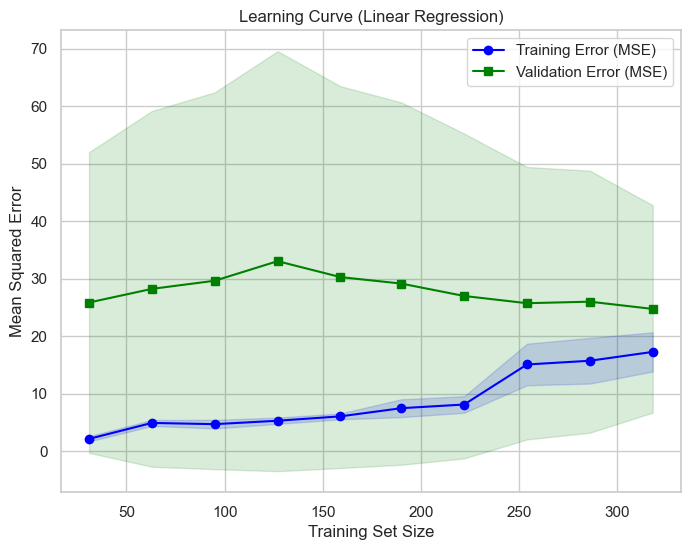


**Behavior Description:**
As the training set size increases, the training error typically rises slightly (harder to perfectly fit more points), while the validation error decreases (the model generalizes better with more data). The curves eventually converge to a similar plateau. A large gap between the curves at the end would indicate overfitting, while converging at a high error indicates underfitting. Here, they converge reasonably well, but the final error might still be lowered by using a more complex model (like Polynomial Degree 2).


In [9]:
# Plot learning curve showing training vs validation error as dataset size increases
train_sizes, train_scores, valid_scores = learning_curve(
    LinearRegression(), X, y, train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='neg_mean_squared_error', cv=5
)

# Calculate mean and standard deviation for training set scores
train_mean = -np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)

# Calculate mean and standard deviation for validation set scores
valid_mean = -np.mean(valid_scores, axis=1)
valid_std = np.std(valid_scores, axis=1)

plt.figure(figsize=(8, 6))
plt.plot(train_sizes, train_mean, label='Training Error (MSE)', color='blue', marker='o')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, color='blue', alpha=0.15)

plt.plot(train_sizes, valid_mean, label='Validation Error (MSE)', color='green', marker='s')
plt.fill_between(train_sizes, valid_mean - valid_std, valid_mean + valid_std, color='green', alpha=0.15)

plt.title('Learning Curve (Linear Regression)')
plt.xlabel('Training Set Size')
plt.ylabel('Mean Squared Error')
plt.legend(loc='best')
plt.show()

text_lc = """
**Behavior Description:**
As the training set size increases, the training error typically rises slightly (harder to perfectly fit more points), while the validation error decreases (the model generalizes better with more data). The curves eventually converge to a similar plateau. A large gap between the curves at the end would indicate overfitting, while converging at a high error indicates underfitting. Here, they converge reasonably well, but the final error might still be lowered by using a more complex model (like Polynomial Degree 2).
"""
display(Markdown(text_lc))


## Question 9 — Validation Curve

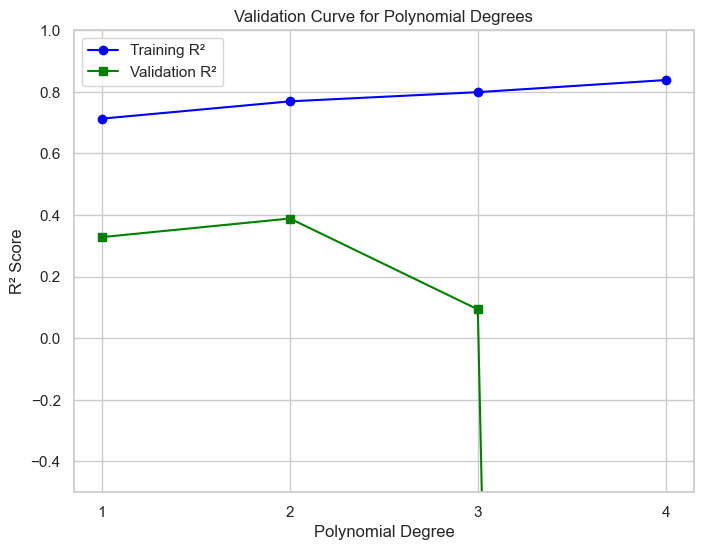


**Best Performance:**
The degree with the best performance is **Degree 2**. Degree 1 (Linear) has a moderate R², Degree 2 peaks with the highest Validation R², and degrees 3+ show a massive drop in Validation R² (often becoming negative) despite high Training R², clearly indicating severe overfitting.


In [10]:
# Plot validation curve (degree vs R²)
degrees = np.arange(1, 5)
train_scores, valid_scores = validation_curve(
    make_pipeline(StandardScaler(), PolynomialFeatures(), LinearRegression()), 
    X, y, param_name="polynomialfeatures__degree", param_range=degrees,
    cv=5, scoring='r2'
)

train_mean = np.mean(train_scores, axis=1)
valid_mean = np.mean(valid_scores, axis=1)

plt.figure(figsize=(8, 6))
plt.plot(degrees, train_mean, label='Training R²', color='blue', marker='o')
plt.plot(degrees, valid_mean, label='Validation R²', color='green', marker='s')

plt.title('Validation Curve for Polynomial Degrees')
plt.xlabel('Polynomial Degree')
plt.ylabel('R² Score')
plt.xticks(degrees)
plt.ylim([-0.5, 1.0]) # Limit y-axis for readability since high degrees get very negative R2
plt.legend(loc='best')
plt.show()

text_vc = """
**Best Performance:**
The degree with the best performance is **Degree 2**. Degree 1 (Linear) has a moderate R², Degree 2 peaks with the highest Validation R², and degrees 3+ show a massive drop in Validation R² (often becoming negative) despite high Training R², clearly indicating severe overfitting.
"""
display(Markdown(text_vc))


## Question 10 — Reflection

In [11]:
text_reflection = """
### Reflection

**Which model performed better and why?**
The Polynomial Regression (Degree 2) model performed better than the simple Linear Regression model because the relationship between MPG and features like weight/horsepower is non-linear (MPG drops exponentially as weight increases, then levels out).

**What degree caused overfitting?**
Degrees 3 and higher caused significant overfitting. The model became too complex, capturing random noise and drastically failing on the validation sets (shown by the massive drop in validation R²).

**How can model generalization be improved?**
Model generalization could be improved by:
1. Using regularization techniques like Ridge or Lasso regression to penalize overly large polynomial coefficients.
2. Increasing the amount of training data.
3. Feature engineering or using a different model architecture (like Random Forests) that naturally handles non-linearities without blowing up the feature space.
"""
display(Markdown(text_reflection))



### Reflection

**Which model performed better and why?**
The Polynomial Regression (Degree 2) model performed better than the simple Linear Regression model because the relationship between MPG and features like weight/horsepower is non-linear (MPG drops exponentially as weight increases, then levels out).

**What degree caused overfitting?**
Degrees 3 and higher caused significant overfitting. The model became too complex, capturing random noise and drastically failing on the validation sets (shown by the massive drop in validation R²).

**How can model generalization be improved?**
Model generalization could be improved by:
1. Using regularization techniques like Ridge or Lasso regression to penalize overly large polynomial coefficients.
2. Increasing the amount of training data.
3. Feature engineering or using a different model architecture (like Random Forests) that naturally handles non-linearities without blowing up the feature space.
